# Practical 4B: Fashion MNIST Classification Using CNN with PyTorch

This notebook builds a CNN to classify Fashion MNIST images into 10 clothing categories using PyTorch and CUDA when available.

In [2]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Libraries imported successfully.")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Libraries imported successfully.


100%|██████████| 26.4M/26.4M [01:06<00:00, 398kB/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 157kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:02<00:00, 2.01MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]
C:\Users\jenil\AppData\Local\Temp\ipykernel_28880\1587851588.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print("Missing values in training labels:", np.isnan(np.array(raw_train_ds.targets)).sum())


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Train shape: 60000 Test shape: 10000
Missing values in training labels: 0


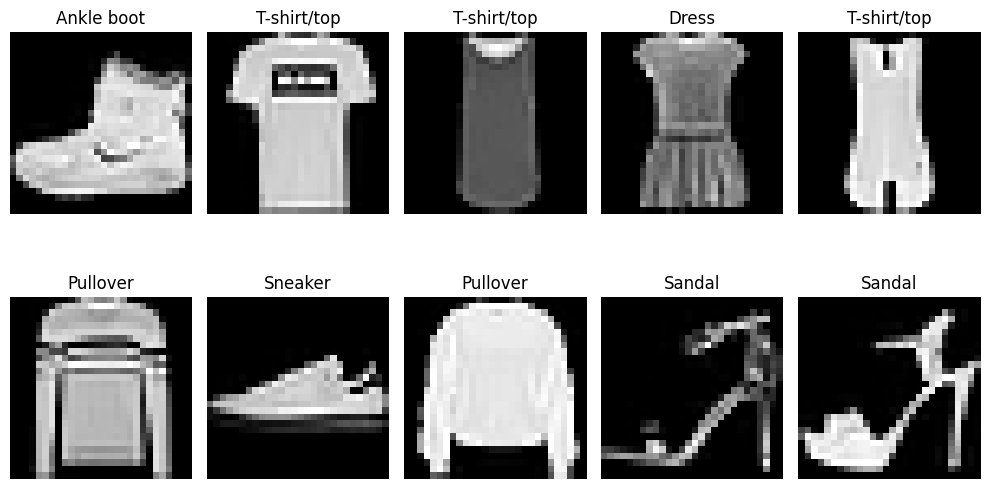

Training samples: 54000
Validation samples: 6000
Test samples: 10000


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

raw_train_ds = datasets.FashionMNIST(root="./data", train=True, download=True)
train_full_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

print("Train shape:", len(raw_train_ds), "Test shape:", len(test_ds))
print("Missing values in training labels:", np.isnan(np.array(raw_train_ds.targets)).sum())

plt.figure(figsize=(10, 6))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(raw_train_ds.data[i].numpy(), cmap="gray")
    plt.title(class_names[raw_train_ds.targets[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

train_size = int(0.9 * len(train_full_ds))
val_size = len(train_full_ds) - train_size
train_ds, val_ds = random_split(train_full_ds, [train_size, val_size], generator=torch.Generator().manual_seed(42))

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))

In [4]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNNClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

print(model)

best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, 8):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "fashion_mnist_cnn.pth")

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

print("Best validation accuracy:", round(best_val_acc, 4))

C:\Users\jenil\AppData\Local\Temp\ipykernel_28880\441318054.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


C:\Users\jenil\AppData\Local\Temp\ipykernel_28880\441318054.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 1: train_loss=0.5703, train_acc=0.7901, val_loss=0.3540, val_acc=0.8673
Epoch 2: train_loss=0.3464, train_acc=0.8748, val_loss=0.2883, val_acc=0.8915
Epoch 3: train_loss=0.2963, train_acc=0.8922, val_loss=0.2679, val_acc=0.8978
Epoch 4: train_loss=0.2647, train_acc=0.9046, val_loss=0.2678, val_acc=0.9005
Epoch 5: train_loss=0.2424, train_acc=0.9126, val_loss=0.2323, val_acc=0.9125
Epoch 6: train_loss=0.2226, train_acc=0.9191, val_loss=0.2333, val_acc=0.9158
Epoch 7: train_loss=0.2055, train_acc=0.9257, val_loss=0.2191, val_acc=0.9187
Best validation accuracy: 0.9187


C:\Users\jenil\AppData\Local\Temp\ipykernel_28880\3803266007.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("fashion_mnist_cnn.pth", ma

Test accuracy: 0.9136

Classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.89      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.88      0.87      1000
       Dress       0.94      0.89      0.91      1000
        Coat       0.85      0.88      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.77      0.72      0.74      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



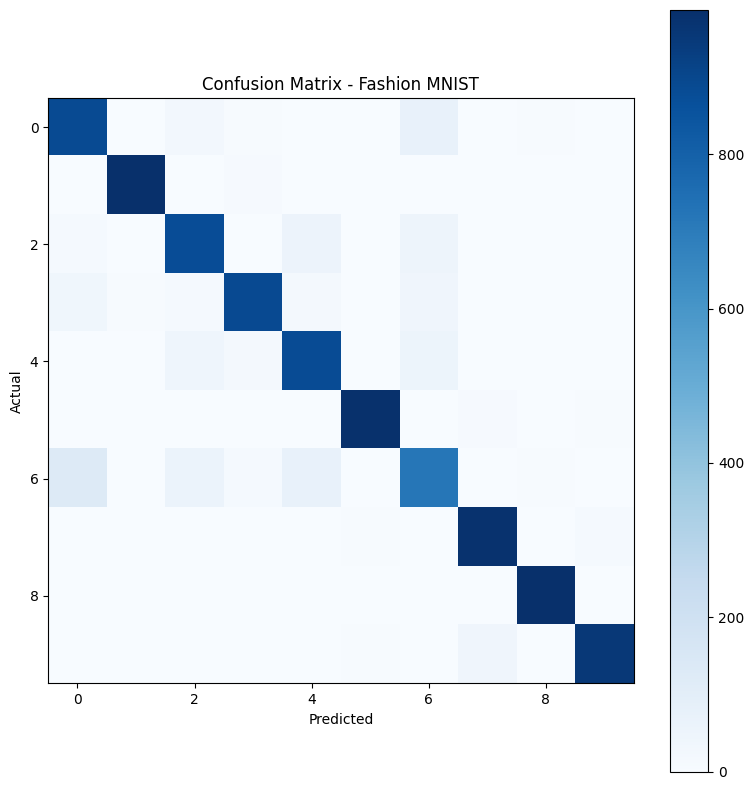

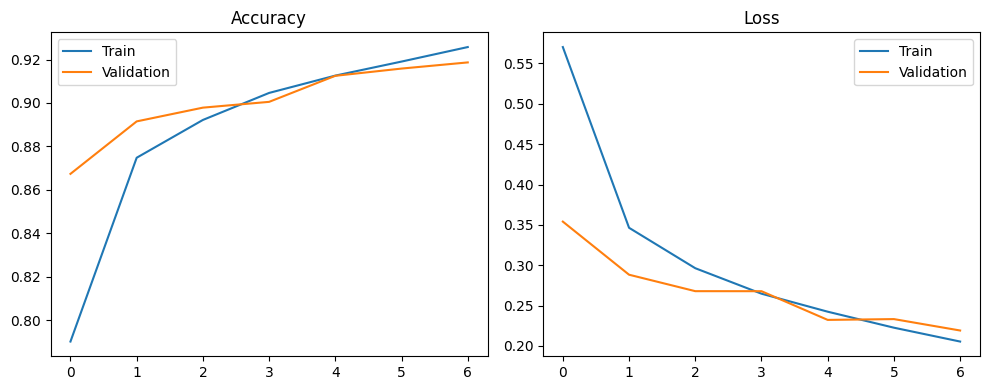

Sample predictions:
Actual: Shirt, Predicted: Shirt
Actual: Dress, Predicted: Dress
Actual: T-shirt/top, Predicted: Shirt
Actual: Sandal, Predicted: Ankle boot
Actual: Pullover, Predicted: Pullover


In [5]:
model.load_state_dict(torch.load("fashion_mnist_cnn.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)
print("Test accuracy:", round(accuracy, 4))
print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Fashion MNIST")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(test_loader.dataset), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    img, label = test_loader.dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
    print(f"Actual: {class_names[label]}, Predicted: {class_names[pred]}")